In [2]:
import numpy as np
import matplotlib.pyplot as plt
import igraph as ig
import json


%load_ext autoreload
%autoreload 2
from src.simulation import run_replicas, simulate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from itertools import product

RANKER_CONFIGS = [
    {'rule': 'Random'},
    {'rule': 'Closest'},
    {'rule': 'Engagement',         'alpha': 1.0},
    {'rule': 'Narrative',          'target_opinion': 0.5},
    {'rule': 'Evil',               'target_opinion': 0.5},
    {'rule': 'Diverse_Engagement'},
    {'rule': 'User_Success',       'alpha': 1.0},
    {'rule': 'Personalization',    'alpha': 1.0},
]

OD_CONFIGS = [
    {'model': 'BCM',          'epsilon': 0.2, 'mu': 0.1},
    {'model': 'BCM_HK',       'epsilon': 0.2, 'mu': 0.1},
    {'model': 'BCM_negative', 'epsilon_1': 0.2, 'epsilon_2': 0.6, 'mu': 0.1},
    {'model': 'BCM_asymmetric', 'epsilon': 0.2, 'mu_1': 0.2, 'mu_2': 0.05},
]

NOISE_VALUES  = [0.0, 0.2]
KPOST_VALUES  = [1, 5]

total = len(OD_CONFIGS) * len(RANKER_CONFIGS) * len(NOISE_VALUES) * len(KPOST_VALUES)
passed = 0
failed = []

print(f"Running {total} combinations...\n")

for od_cfg, ranker_cfg, noise, k_posts in product(OD_CONFIGS, RANKER_CONFIGS, NOISE_VALUES, KPOST_VALUES):
    INFO = {
        "General": {"seed": 42},
        "Graph": {"type": "ER", "n": 100, "p": 0.1},
        "OD": od_cfg,
        "Ranker": ranker_cfg,
        "Simulation_details": {"n_steps": 500, "convergence_window": 50, "convergence_delta": 1e-4},
        "k_posts": k_posts,
        "post_history": 50,
        "noise": noise,
    }

    label = f"{od_cfg['model']} + {ranker_cfg['rule']} | noise={noise} k={k_posts}"
    try:
        for rep in range(3):
            r = simulate(INFO, seed=42 + rep)
        print(f"OK    {label}  conv={r['convergence_step']}  pol={r['pol'][r['convergence_step']]*4:.3f}")
        passed += 1
    except Exception as e:
        print(f"FAIL  {label}  ERROR: {e}")
        failed.append((label, e))

print(f"\n--- {passed}/{total} passed ---")
if failed:
    print("Failures:")
    for label, e in failed:
        print(f"  {label}: {e}")

Running 16 combinations...

OK    BCM + Personalization | noise=0.0 k=1  conv=499  pol=0.108
OK    BCM + Personalization | noise=0.0 k=5  conv=101  pol=0.244
OK    BCM + Personalization | noise=0.2 k=1  conv=499  pol=0.108
OK    BCM + Personalization | noise=0.2 k=5  conv=101  pol=0.244
OK    BCM_HK + Personalization | noise=0.0 k=1  conv=499  pol=0.108
OK    BCM_HK + Personalization | noise=0.0 k=5  conv=499  pol=0.058
OK    BCM_HK + Personalization | noise=0.2 k=1  conv=499  pol=0.108
OK    BCM_HK + Personalization | noise=0.2 k=5  conv=499  pol=0.058
OK    BCM_negative + Personalization | noise=0.0 k=1  conv=133  pol=0.811
OK    BCM_negative + Personalization | noise=0.0 k=5  conv=101  pol=0.799
OK    BCM_negative + Personalization | noise=0.2 k=1  conv=133  pol=0.811
OK    BCM_negative + Personalization | noise=0.2 k=5  conv=101  pol=0.799
OK    BCM_asymmetric + Personalization | noise=0.0 k=1  conv=249  pol=0.194
OK    BCM_asymmetric + Personalization | noise=0.0 k=5  conv=101  po

In [52]:
info = {
    "Graph": {"type": "ER", "n": 1000, "p": 0.01},
    "OD": {"model": "BCM", "epsilon": 0.3, "mu": 0.1},
    "Ranker": {"rule": "Random"},
    "Simulation_details": {"n_steps": 500, "convergence_window": 50, "convergence_delta": 1e-4},
    "post_history": 50,
    "k_posts": 3,
}

result = simulate(info)

print(f"Convergence step: {result['convergence_step']}")
print(f"Final polarization: {result['pol'][result['convergence_step']]:.6f}")
print(f"Final mean opinion: {result['final_opinions'].mean():.6f}")
print(f"Final opinions (first 10): {result['final_opinions'][:10]}")

Convergence step: 101
Final polarization: 0.001190
Final mean opinion: 0.494206
Final opinions (first 10): [0.4933427  0.49334819 0.49335203 0.49335063 0.49335314 0.49334697
 0.49334926 0.49335608 0.4933523  0.49335084]


In [56]:
# print the list of keys in the result dictionary
print("Result keys:", result.keys())

Result keys: dict_keys(['G', 'pol', 'filter_bubble', 'homophily', 'opinions', 'convergence_step', 'final_opinions', 'final_likes'])


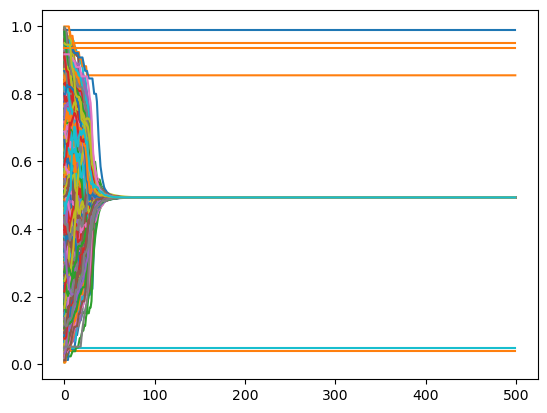

In [62]:
import matplotlib.pyplot as plt
info = {
    "Graph": {"type": "ER", "n": 1000, "p": 0.01},
    "OD": {"model": "BCM", "epsilon": 0.3, "mu": 0.1},
    "Ranker": {"rule": "Random"},
    "Simulation_details": {"n_steps": 500, "convergence_window": 50, "convergence_delta": 1e-4},
    "post_history": 50,
    "k_posts": 3,
}

result = simulate(info)
plt.plot(result["opinions"])

In [26]:
info = {
    "Graph": {"type": "ER", "n": 100, "p": 0.1},
    "OD": {"model": "BCM", "epsilon": 0.3, "mu": 0.1},
    "Ranker": {"rule": "Random"},
    "Simulation_details": {"n_steps": 500, "convergence_window": 50, "convergence_delta": 1e-4},
    "post_history": 50,
    "k_posts": 3,
}

result = simulate(info)

print(f"Convergence step: {result['convergence_step']}")
print(f"Final polarization: {result['pol'][result['convergence_step']]:.6f}")
print(f"Final mean opinion: {result['final_opinions'].mean():.6f}")
print(f"Final opinions (first 10): {result['final_opinions'][:10]}")

Convergence step: 101
Final polarization: 0.001667
Final mean opinion: 0.459904
Final opinions (first 10): [0.45580082 0.45579984 0.45579918 0.45580071 0.45580572 0.45579947
 0.45580166 0.86617615 0.45580136 0.45580615]


In [34]:
import cProfile
import pstats

info = {
    "Graph": {"type": "ER", "n": 1000, "p": 0.01},
    "OD": {"model": "BCM", "epsilon": 0.3, "mu": 0.1},
    "Ranker": {"rule": "Random"},
    "Simulation_details": {"n_steps": 500, "convergence_window": 50, "convergence_delta": 1e-4},
    "post_history": 50,
    "k_posts": 3,
}

profiler = cProfile.Profile()
profiler.enable()
result = simulate(info)
profiler.disable()

print(f"Convergence step: {result['convergence_step']}")
print(f"Final polarization: {result['pol'][result['convergence_step']]:.6f}")
print(f"Final mean opinion: {result['final_opinions'].mean():.6f}")
print(f"Final opinions (first 10): {result['final_opinions'][:10]}")

stats = pstats.Stats(profiler)
stats.sort_stats('cumulative')
stats.print_stats(20)  # top 20 functions

Convergence step: 101
Final polarization: 0.001190
Final mean opinion: 0.494206
Final opinions (first 10): [0.4933427  0.49334819 0.49335203 0.49335063 0.49335314 0.49334697
 0.49334926 0.49335608 0.4933523  0.49335084]
         344983 function calls in 2.678 seconds

   Ordered by: cumulative time
   List reduced from 89 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    2.678    1.339 c:\Users\nel_t\anaconda3\envs\Ranker\Lib\site-packages\IPython\core\interactiveshell.py:3665(run_code)
        2    0.000    0.000    2.678    1.339 {built-in method builtins.exec}
        1    0.001    0.001    2.678    2.678 C:\Users\nel_t\AppData\Local\Temp\ipykernel_17244\3546284989.py:1(<module>)
        1    0.005    0.005    2.677    2.677 c:\Users\nel_t\Documents\WORK\PROJECTS\Rankers\src\simulation.py:1(simulate)
      102    2.339    0.023    2.382    0.023 c:\Users\nel_t\Documents\WORK\PROJECTS\Rankers\src\rank

In [51]:
import cProfile
import pstats

info = {
    "Graph": {"type": "ER", "n": 1000, "p": 0.01},
    "OD": {"model": "BCM", "epsilon": 0.3, "mu": 0.1},
    "Ranker": {"rule": "User_Success", "alpha": 1.0},
    "Simulation_details": {"n_steps": 500, "convergence_window": 50, "convergence_delta": 1e-4},
    "post_history": 50,
    "k_posts": 3,
}

profiler = cProfile.Profile()
profiler.enable()
result = simulate(info)
profiler.disable()

print(f"Convergence step: {result['convergence_step']}")
print(f"Final polarization: {result['pol'][result['convergence_step']]:.6f}")
print(f"Final mean opinion: {result['final_opinions'].mean():.6f}")
print(f"Final opinions (first 10): {result['final_opinions'][:10]}")

stats = pstats.Stats(profiler)
stats.sort_stats('cumulative')
stats.print_stats(20)  # top 20 functions

Convergence step: 101
Final polarization: 0.002804
Final mean opinion: 0.491310
Final opinions (first 10): [0.48907559 0.48908363 0.48909611 0.48909904 0.48909075 0.48908118
 0.48909701 0.48909023 0.48909847 0.48908792]
         848469 function calls in 4.804 seconds

   Ordered by: cumulative time
   List reduced from 92 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    4.806    2.403 c:\Users\nel_t\anaconda3\envs\Ranker\Lib\site-packages\IPython\core\interactiveshell.py:3665(run_code)
        2    0.000    0.000    4.806    2.403 {built-in method builtins.exec}
        1    0.005    0.005    4.804    4.804 c:\Users\nel_t\Documents\WORK\PROJECTS\Rankers\src\simulation.py:1(simulate)
      102    3.762    0.037    4.519    0.044 c:\Users\nel_t\Documents\WORK\PROJECTS\Rankers\src\rankers\user_success.py:1(rank)
   100495    0.133    0.000    0.616    0.000 c:\Users\nel_t\anaconda3\envs\Ranker\Lib\site-pa